In [9]:
# =========================================================
# SMART WASTE CLASSIFICATION SYSTEM
# Image Classification using CNN + Transfer Learning
# =========================================================

# ===============================
# Import Libraries
# ===============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, accuracy_score


# ===============================
# CONSTANTS
# ===============================
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

CNN_EPOCHS = 15
TL_EPOCHS = 10

BASE_DIR = "dataset"


# =========================================================
# TASK 1 — DATASET STRUCTURE & IMAGE COUNT
# =========================================================

print("\n==============================")
print("TASK 1 — DATASET VERIFICATION")
print("==============================\n")

splits = ["train","validation"]
categories = ["recyclable","organic","non_recyclable"]

for split in splits:
    
    print("Directory:",split)
    
    total = 0
    
    for category in categories:
        
        folder = os.path.join(BASE_DIR,split,category)
        
        if os.path.exists(folder):
            count = len(os.listdir(folder))
            print(category,":",count,"images")
            total += count
        else:
            print(category,"folder not found")
    
    print("Total images:",total,"\n")


# =========================================================
# TASK 2 — DATA PREPROCESSING
# =========================================================

print("\n==============================")
print("TASK 2 — DATA PREPROCESSING")
print("==============================\n")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=30,
    
    horizontal_flip=True,
    
    zoom_range=0.2,
    
    brightness_range=[0.8,1.2]
)

# Validation generator
validation_datagen = ImageDataGenerator(
    
    rescale=1./255
)

# Load training dataset
train_generator = train_datagen.flow_from_directory(
    
    os.path.join(BASE_DIR,"train"),
    
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode="categorical"
)

# Load validation dataset
validation_generator = validation_datagen.flow_from_directory(
    
    os.path.join(BASE_DIR,"validation"),
    
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode="categorical",
    
    shuffle=False
)


# =========================================================
# TASK 3 — CUSTOM CNN MODEL
# =========================================================

print("\n==============================")
print("TASK 3 — CNN MODEL TRAINING")
print("==============================\n")

model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(IMG_HEIGHT,IMG_WIDTH,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(3,activation="softmax"))

model.compile(

    optimizer="adam",
    
    loss="categorical_crossentropy",
    
    metrics=["accuracy"]
)

model.summary()


# ===============================
# TRAIN MODEL
# ===============================

history = model.fit(

    train_generator,
    
    epochs=CNN_EPOCHS,
    
    validation_data=validation_generator
)


# ===============================
# ACCURACY GRAPH
# ===============================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])


plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()



# =========================================================
# TASK 4 — MODEL EVALUATION
# =========================================================

print("\n==============================")
print("TASK 4 — MODEL EVALUATION")
print("==============================\n")

validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions,axis=1)

y_true = validation_generator.classes


# ===============================
# Accuracy Score
# ===============================

accuracy = accuracy_score(y_true,y_pred)

print("CNN Accuracy Score:",accuracy*100,"%")



# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_true,y_pred)

class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(7,5))

sns.heatmap(cm,

            annot=True,
            
            fmt="d",
            
            cmap="Blues",
            
            xticklabels=class_names,
            
            yticklabels=class_names)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()



# ===============================
# SAMPLE PREDICTIONS
# ===============================

images,labels = next(validation_generator)

sample_preds = model.predict(images[:5])

pred_classes = np.argmax(sample_preds,axis=1)

true_classes = np.argmax(labels[:5],axis=1)

plt.figure(figsize=(15,4))

for i in range(5):
    
    plt.subplot(1,5,i+1)
    
    plt.imshow(images[i])
    
    pred = class_names[pred_classes[i]]
    
    true = class_names[true_classes[i]]
    
    color = "green" if pred==true else "red"
    
    plt.title("Pred:"+pred+"\nTrue:"+true,color=color)
    
    plt.axis("off")

plt.show()



# =========================================================
# TASK 5 — TRANSFER LEARNING (MobileNetV2)
# =========================================================

print("\n==============================")
print("TASK 5 — TRANSFER LEARNING")
print("==============================\n")


# Load pretrained model
base_model = MobileNetV2(

    weights="imagenet",
    
    include_top=False,
    
    input_shape=(IMG_HEIGHT,IMG_WIDTH,3)
)

# Freeze layers
base_model.trainable = False


# Build Transfer Learning model
tl_model = Sequential([

    base_model,
    
    GlobalAveragePooling2D(),
    
    Dense(128,activation="relu"),
    
    Dropout(0.5),
    
    Dense(3,activation="softmax")
])


tl_model.compile(

    optimizer="adam",
    
    loss="categorical_crossentropy",
    
    metrics=["accuracy"]
)

tl_model.summary()


# ===============================
# Train Transfer Model
# ===============================

tl_history = tl_model.fit(

    train_generator,
    
    epochs=TL_EPOCHS,
    
    validation_data=validation_generator
)



# =========================================================
# FINAL COMPARISON
# =========================================================

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")

cnn_val_acc = history.history["val_accuracy"][-1]

tl_val_acc = tl_history.history["val_accuracy"][-1]

print("Custom CNN Validation Accuracy:",cnn_val_acc*100,"%")

print("MobileNetV2 Validation Accuracy:",tl_val_acc*100,"%")


TASK 1 — DATASET VERIFICATION

Directory: train
recyclable folder not found
organic folder not found
non_recyclable folder not found
Total images: 0 

Directory: validation
recyclable folder not found
organic folder not found
non_recyclable folder not found
Total images: 0 


TASK 2 — DATA PREPROCESSING



FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset\\train'

In [10]:
import os

folders = [
    "dataset/train/recyclable",
    "dataset/train/organic",
    "dataset/train/non_recyclable",
    "dataset/validation/recyclable",
    "dataset/validation/organic",
    "dataset/validation/non_recyclable"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Dataset folders created successfully!")

Dataset folders created successfully!


In [11]:
import os

base = "dataset"

for split in ["train","validation"]:
    print("\n",split)
    
    path = os.path.join(base,split)
    
    for cls in os.listdir(path):
        print(cls,len(os.listdir(os.path.join(path,cls))))


 train
non_recyclable 2
organic 2
recyclable 2

 validation
non_recyclable 2
organic 2
recyclable 2


In [12]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR,"train"),
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 2527 images belonging to 3 classes.


TASK 2: DATA PREPROCESSING
Found 2527 images belonging to 3 classes.
Found 2527 images belonging to 3 classes.
TASK 3: CNN MODEL TRAINING


c:\Users\Aditya\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4250 - loss: 1.1540 - val_accuracy: 0.5469 - val_loss: 0.9057
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 851ms/step - accuracy: 0.5417 - loss: 0.9518 - val_accuracy: 0.5568 - val_loss: 0.8995
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.5334 - loss: 0.9554 - val_accuracy: 0.5857 - val_loss: 0.8779
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 67s 848ms/step - accuracy: 0.5572 - loss: 0.9196 - val_accuracy: 0.5880 - val_loss: 0.8747
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5691 - loss: 0.8816 - val_accuracy: 0.5797 - val_loss: 0.8830


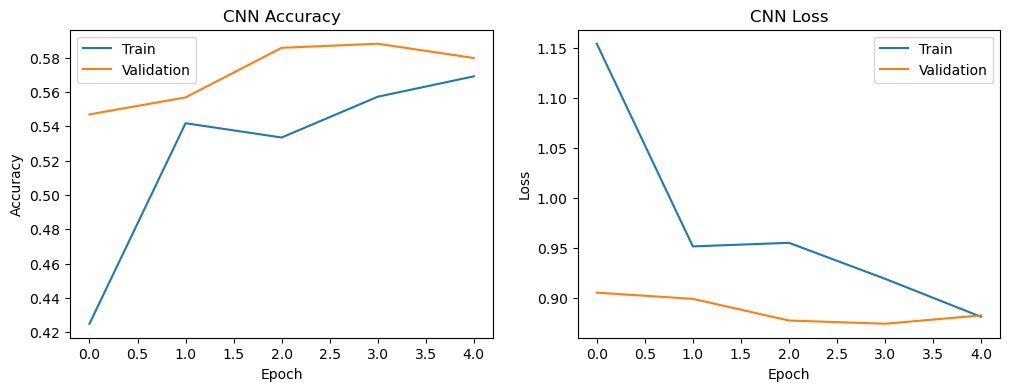

TASK 4: MODEL EVALUATION
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step
CNN Accuracy: 57.97388207360507 %


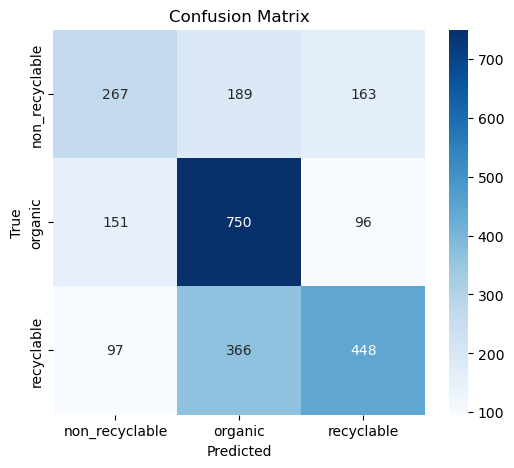

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


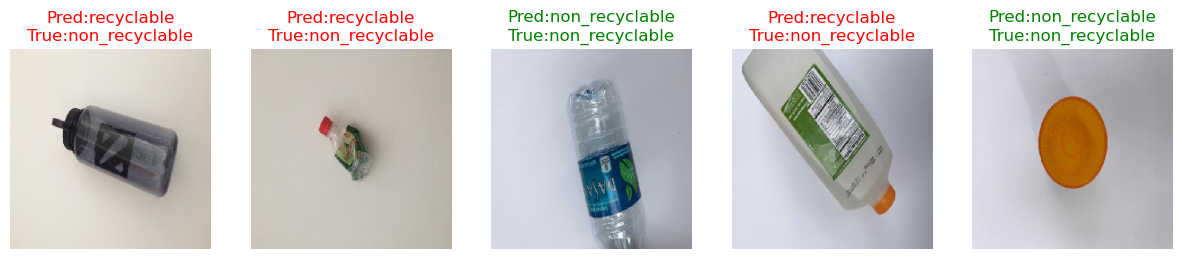

TASK 5: TRANSFER LEARNING


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 66s 797ms/step - accuracy: 0.7459 - loss: 0.5944 - val_accuracy: 0.8298 - val_loss: 0.4021
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8385 - loss: 0.4094 - val_accuracy: 0.8837 - val_loss: 0.2829
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 788ms/step - accuracy: 0.8484 - loss: 0.3581 - val_accuracy: 0.9082 - val_loss: 0.2600


FINAL MODEL COMPARISON
Custom CNN Validation Accuracy: 57.97387957572937 %
MobileNetV2 Validation Accuracy: 90.81915020942688 %

Model saved as waste_classifier_model.h5


In [1]:
# =========================================================
# SMART WASTE CLASSIFICATION SYSTEM
# Complete Pipeline: Dataset Check → Preprocessing → CNN →
# Evaluation → Transfer Learning → Comparison
# =========================================================

# ===============================
# IMPORT LIBRARIES
# ===============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import confusion_matrix, accuracy_score

# CONSTANTS

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

CNN_EPOCHS = 5
TL_EPOCHS = 3

BASE_DIR = "dataset"


# TASK 2 — DATA PREPROCESSING

print("TASK 2: DATA PREPROCESSING")


train_datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=30,
    
    horizontal_flip=True,
    
    zoom_range=0.2,
    
    brightness_range=[0.8,1.2]
)

validation_datagen = ImageDataGenerator(
    
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    
    os.path.join(BASE_DIR,"train"),
    
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode="categorical"
)

validation_generator = validation_datagen.flow_from_directory(
    
    os.path.join(BASE_DIR,"validation"),
    
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    
    batch_size=BATCH_SIZE,
    
    class_mode="categorical",
    
    shuffle=False
)

# TASK 3 — CUSTOM CNN MODEL

print("TASK 3: CNN MODEL TRAINING")


model = Sequential([

    Conv2D(32,(3,3),activation="relu",input_shape=(IMG_HEIGHT,IMG_WIDTH,3)),
    
    MaxPooling2D(2,2),
    
    Conv2D(64,(3,3),activation="relu"),
    
    MaxPooling2D(2,2),
    
    Conv2D(128,(3,3),activation="relu"),
    
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(128,activation="relu"),
    
    Dropout(0.5),
    
    Dense(3,activation="softmax")
])

model.compile(
    
    optimizer="adam",
    
    loss="categorical_crossentropy",
    
    metrics=["accuracy"]
)

model.summary()

# Train CNN
history = model.fit(
    
    train_generator,
    
    epochs=CNN_EPOCHS,
    
    validation_data=validation_generator
)


# ACCURACY GRAPH

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])


plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()


# TASK 4 — MODEL EVALUATION

print("TASK 4: MODEL EVALUATION")


validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions,axis=1)

y_true = validation_generator.classes


# Accuracy Score
accuracy = accuracy_score(y_true,y_pred)

print("CNN Accuracy:",accuracy*100,"%")


# CONFUSION MATRIX

cm = confusion_matrix(y_true,y_pred)

class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(6,5))

sns.heatmap(cm,

            annot=True,
            
            fmt="d",
            
            cmap="Blues",
            
            xticklabels=class_names,
            
            yticklabels=class_names)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()




# SAMPLE PREDICTIONS

images,labels = next(validation_generator)

sample_preds = model.predict(images[:5])

pred_classes = np.argmax(sample_preds,axis=1)

true_classes = np.argmax(labels[:5],axis=1)

plt.figure(figsize=(15,4))

for i in range(5):
    
    plt.subplot(1,5,i+1)
    
    plt.imshow(images[i])
    
    pred = class_names[pred_classes[i]]
    
    true = class_names[true_classes[i]]
    
    color = "green" if pred==true else "red"
    
    plt.title("Pred:"+pred+"\nTrue:"+true,color=color)
    
    plt.axis("off")

plt.show()


# TASK 5 — TRANSFER LEARNING (MobileNetV2)

print("TASK 5: TRANSFER LEARNING")


base_model = MobileNetV2(

    weights="imagenet",
    
    include_top=False,
    
    input_shape=(IMG_HEIGHT,IMG_WIDTH,3)
)

base_model.trainable = False

tl_model = Sequential([

    base_model,
    
    GlobalAveragePooling2D(),
    
    Dense(128,activation="relu"),
    
    Dropout(0.5),
    
    Dense(3,activation="softmax")
])

tl_model.compile(

    optimizer="adam",
    
    loss="categorical_crossentropy",
    
    metrics=["accuracy"]
)

tl_model.summary()


# Train Transfer Model
tl_history = tl_model.fit(
    
    train_generator,
    
    epochs=TL_EPOCHS,
    
    validation_data=validation_generator
)



# FINAL COMPARISON

print("FINAL MODEL COMPARISON")


cnn_acc = history.history["val_accuracy"][-1]

tl_acc = tl_history.history["val_accuracy"][-1]

print("Custom CNN Validation Accuracy:",cnn_acc*100,"%")

print("MobileNetV2 Validation Accuracy:",tl_acc*100,"%")



# SAVE MODEL

model.save("waste_classifier_model.h5")

print("\nModel saved as waste_classifier_model.h5")